In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB # for discrete features
from sklearn.naive_bayes import GaussianNB # for continuous features, using normal distribution to classify

In [4]:
df_dia = pd.read_csv('/content/diabetes-3.csv')

In [6]:
df_dia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df_dia.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [10]:
df_dia.isnull().sum().sum()

np.int64(0)

In [11]:
df_dia.duplicated().sum()

np.int64(0)

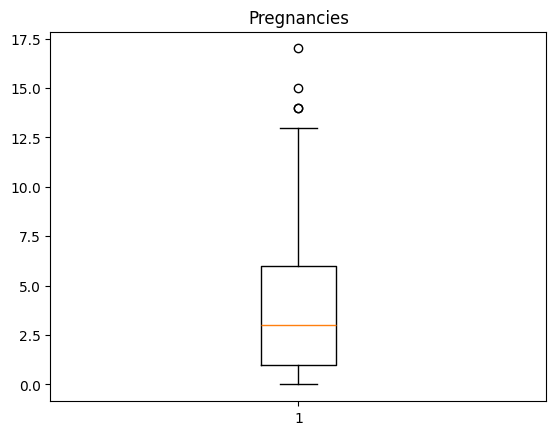

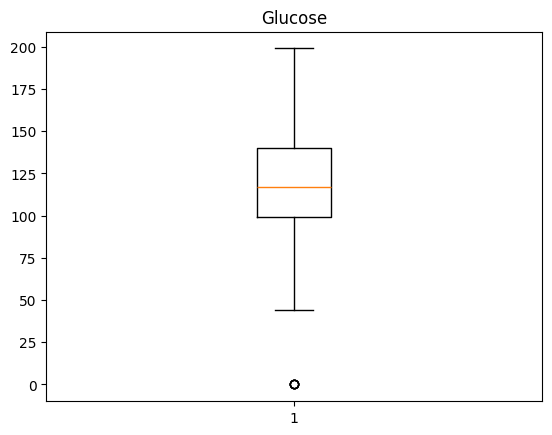

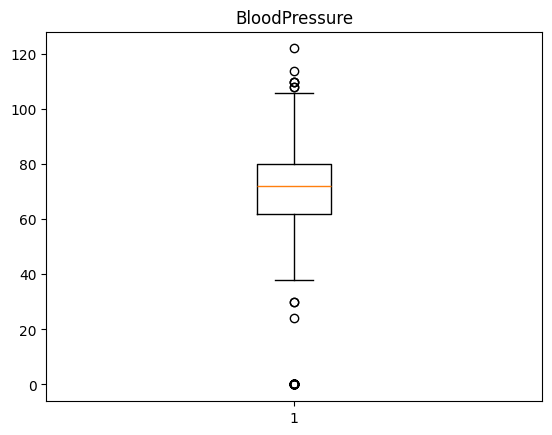

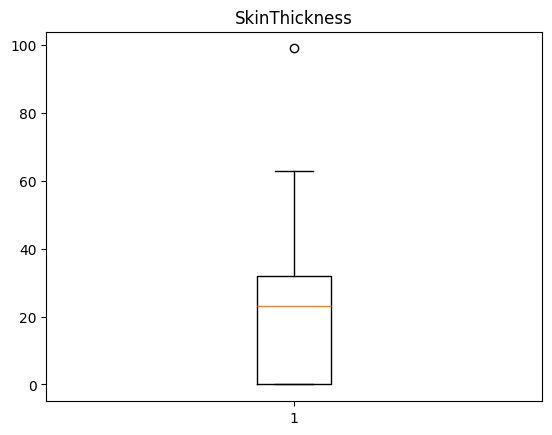

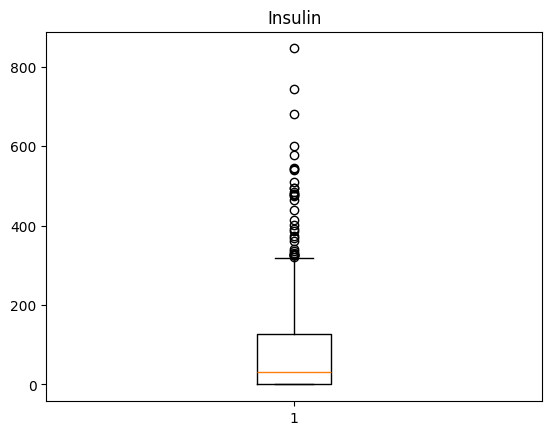

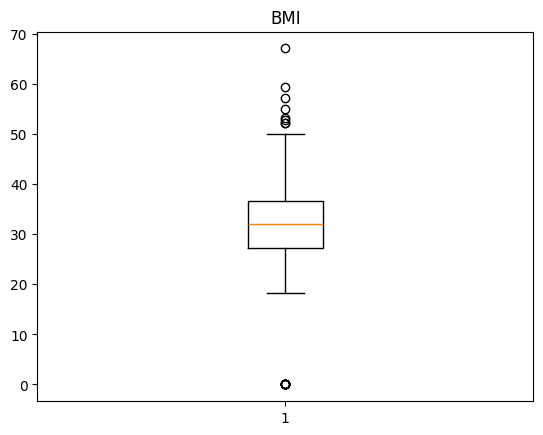

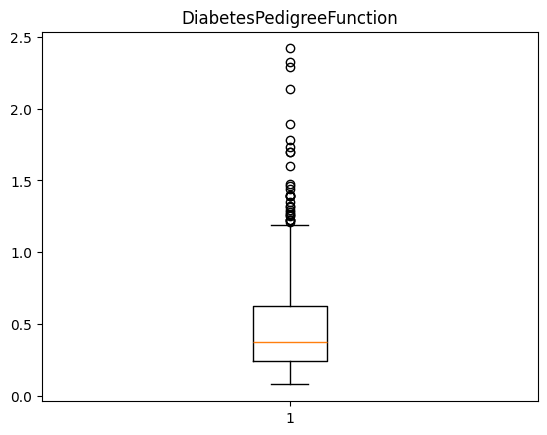

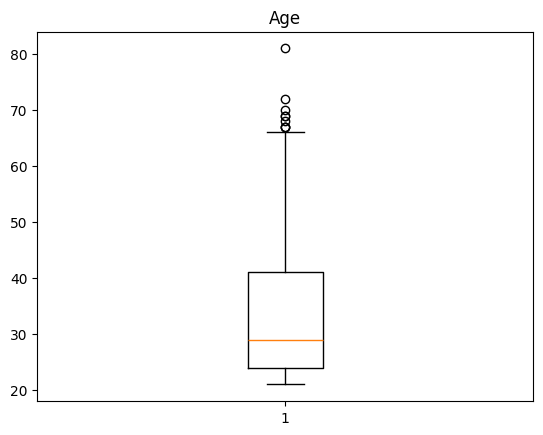

In [5]:
for c in df_dia.columns[:-1]:
  if df_dia[c].dtype != 'object':
    plt.boxplot(df_dia[c])
    plt.title(c)
    plt.show()


In [6]:
# remove outliers in all columns:
for c in df_dia.columns[:-1]:
  q1 = df_dia[c].quantile(0.25)
  q3 = df_dia[c].quantile(0.75)
  iqr = q3 - q1
  lower_limit = q1 - iqr * 1.5
  upper_limit = q3 + iqr * 1.5
  df_dia = df_dia[(df_dia[c] >= lower_limit) & (df_dia[c] <= upper_limit)]



<Axes: >

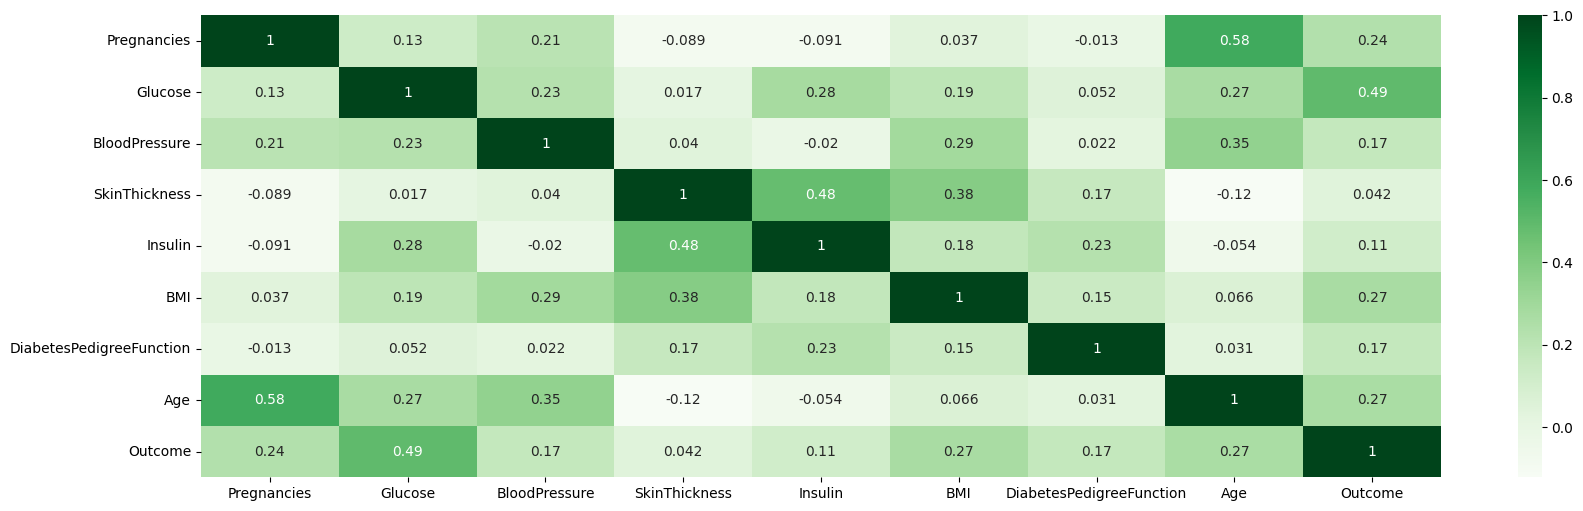

In [9]:
#plot to check correlation coefficient
plt.figure(figsize=(20,6))
sns.heatmap(df_dia.corr(), cmap='Greens', annot=True)
# Naive Bayes assumption - all features are independent

In [11]:
X = df_dia.iloc[:, :-1]
y = df_dia['Outcome']

In [12]:
model = GaussianNB()

In [13]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
model.fit(x_train, y_train)

GaussianNB()

In [15]:
y_pred = model.predict(x_test)

In [16]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [17]:
accuracy_score(y_test, y_pred)

0.7225130890052356